## RETAIL SALES DATA ACQUISITION, PREPROCESSING, AND EXPLORATORY ANALYSIS


### CASE STUDY


### Submitted by - SHREYA FAUSTINA RAJ (25SSDS170014)

### Problem Statement
Retail transaction data is often incomplete and noisy, with missing values and outliers that can reduce the reliability of the analysis. This study focuses on systematically acquiring, cleaning, and preprocessing retail sales data to enable accurate and meaningful insights. It examines key questions related to revenue-driving product categories and locations, spending behaviour across time periods, payment methods, and the relationships between price, quantity, and total expenditure. Additionally, it explores the use of PCA (Principal Component Analysis) for dimensionality reduction while preserving variance. Overall, the work highlights the importance of robust data preprocessing in supporting reliable retail decision-making.

In [1]:
import pandas as pd 
data = pd.read_csv("retail_store_sales.csv")
data

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [3]:
data.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

### Interpretation:
The retail sales dataset consists of missing values mainly present in Item, Price Per Unit, Quantity, Total Spent, and Discount Applied columns. Missing numerical values may have occurred due to incomplete transaction records and can be handled using statistical methods, while missing discount values likely indicate transactions where no discount was applied.

In [4]:
data.duplicated().sum()

np.int64(0)

### Interpretation: 
A duplicate record would mean that the same transaction with identical values across all columns appears more than once. Since the output is zero, it confirms that every transaction entry in the dataset is unique, which is a positive indicator of data integrity.

### Data Cleaning
> Handling Missing Values

In [5]:
def skewness(skew_value):
    if -0.5 <= skew_value <= 0.5:
        return("Approximately normal")
    elif (-1 <= skew_value < -0.5) or (0.5 < skew_value <=1):
        return("Moderately skewed")
    else:
        return ("Highly skewed")

In [6]:
numeric_cols = data.select_dtypes(include=['number']).columns
results = []
for col in numeric_cols:
    skew_val = data[col].skew()
    category = skewness(skew_val)

    results.append({"Column Name":col,"Skew Value": round(skew_val,3),"Skewness":category})
    
report=pd.DataFrame(results)
report

,Column Name,Skew Value,Skewness
0,Price Per Unit,-0.035,Approximately normal
1,Quantity,-0.012,Approximately normal
2,Total Spent,0.831,Moderately skewed


### Interpretation: 
The skewness report provides an initial understanding of the distribution shape of each numerical column in the dataset. Columns with a skew value between -0.5 and 0.5 are approximately normally distributed, meaning their values are symmetrically spread around the mean as shown for Price Per Unit and Quantity feature. Columns with moderate skewness (between ±0.5 and ±1) suggest a slight lean toward either lower or higher values as shown in Total Spent feature , while highly skewed columns (beyond ±1) indicate the presence of extreme values or an imbalanced distribution. This analysis is crucial before imputing missing values, as it helps determine whether the mean, median or mode is a more appropriate fill strategy. 

In [7]:
data['Price Per Unit'] = data['Price Per Unit'].fillna(data['Price Per Unit'].mean())
data['Quantity'] = data['Quantity'].fillna(data['Quantity'].mean())
data['Total Spent'] = data['Total Spent'].fillna(data['Price Per Unit'] * data['Quantity'])
data['Item'] = data['Item'].fillna(data['Item'].mode()[0])
data['Discount Applied'] = data['Discount Applied'].astype('boolean')
data['Discount Applied'] = data['Discount Applied'].fillna(False)

In [8]:
data.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

### Interpretation: 
After applying the missing value handling procedures the dataset is now complete. Numerical columns such as Price Per Unit and Quantity were filled using their respective column means, which is a common approach for approximately distributed data. Total Spent values were recomputed as the product of the filled Price Per Unit and Quantity, ensuring consistency between related columns. The Item column was imputed using the mode (the most frequently occurring item) which is appropriate for categorical data. Discount Applied missing values were interpreted as "no discount" and filled with False, a decision that reflects real-world retail behavior.

> Outlier Detection

In [9]:
data[["Price Per Unit" , "Quantity" , "Total Spent"]].skew()

Price Per Unit   -0.035856
Quantity         -0.012245
Total Spent       0.825288
dtype: float64

In [10]:
numeric_cols = data.select_dtypes(include=['number']).columns
results = []
for col in numeric_cols:
    skew_val = data[col].skew()
    category = skewness(skew_val)

    results.append({"Column Name":col,"Skew Value": round(skew_val,3),"Skewness":category})
    
report=pd.DataFrame(results)
report

,Column Name,Skew Value,Skewness
0,Price Per Unit,-0.036,Approximately normal
1,Quantity,-0.012,Approximately normal
2,Total Spent,0.825,Moderately skewed


In [11]:
Q1 = data["Price Per Unit"].quantile(0.25)
Q3 = data["Price Per Unit"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data["Price Per Unit"] < lower) | (data["Price Per Unit"] > upper)]
outliers

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [12]:
Q1 = data["Quantity"].quantile(0.25)
Q3 = data["Quantity"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data["Quantity"] < lower) | (data["Quantity"] > upper)]
outliers

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [13]:
Q1 = data["Total Spent"].quantile(0.25)
Q3 = data["Total Spent"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data["Total Spent"] < lower) | (data["Total Spent"] > upper)]
outliers

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
27,TXN_1599706,CUST_14,Furniture,Item_25_FUR,41.000000,10.0,410.0,Credit Card,In-store,2024-03-24,True
133,TXN_2953434,CUST_25,Furniture,Item_25_FUR,41.000000,10.0,410.0,Credit Card,In-store,2023-08-10,False
339,TXN_4374445,CUST_12,Food,Item_25_FOOD,41.000000,10.0,410.0,Digital Wallet,Online,2024-10-17,False
869,TXN_1814138,CUST_06,Beverages,Item_25_BEV,41.000000,10.0,410.0,Credit Card,In-store,2024-11-16,False
1060,TXN_3710081,CUST_25,Furniture,Item_25_FUR,41.000000,10.0,410.0,Digital Wallet,In-store,2023-08-12,False
1088,TXN_1273334,CUST_22,Beverages,Item_25_BEV,41.000000,10.0,410.0,Digital Wallet,In-store,2022-11-04,True
1468,TXN_1938135,CUST_17,Butchers,Item_25_BUT,41.000000,10.0,410.0,Digital Wallet,In-store,2023-12-20,True
1505,TXN_8520397,CUST_12,Electric household essentials,Item_25_EHE,41.000000,10.0,410.0,Credit Card,Online,2024-03-27,True
1568,TXN_8048041,CUST_14,Butchers,Item_25_BUT,41.000000,10.0,410.0,Credit Card,In-store,2023-12-25,True
1950,TXN_1860120,CUST_01,Furniture,Item_25_FUR,41.000000,10.0,410.0,Digital Wallet,Online,2022-01-19,True


### Interpretation: 
The IQR-based outlier detection was applied to the three key numerical columns: Price Per Unit, Quantity, and Total Spent.The results help identify whether any transactions involved unusually high prices, abnormally large quantities, or exceptionally high or low spending amounts that could alter statistical summaries. For price per unit and quantity the retail data is uniform in pricing and purchase volume. Although for Total spent certain transactions appeared frequently with identical values (e.g., Price = 41, Quantity = 10, Total Spent = 410), these are not statistical outliers. They represent valid and recurring transaction patterns within the dataset. Outlier detection using the IQR method confirmed that these values fall within acceptable distribution limits, indicating structured and consistent retail pricing behavior rather than anomalies. 

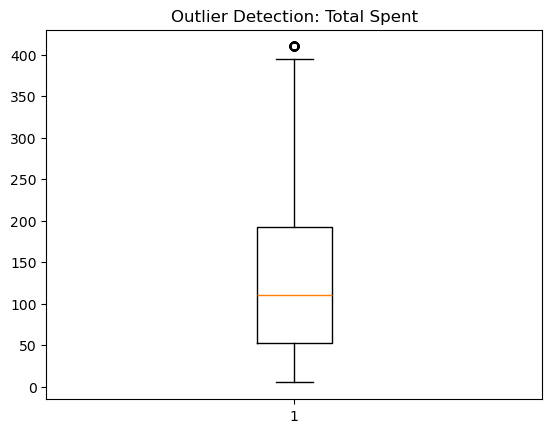

In [14]:
import matplotlib.pyplot as plt
plt.boxplot(data["Total Spent"])
plt.title("Outlier Detection: Total Spent")
plt.show()

<Axes: xlabel='Total Spent', ylabel='Count'>

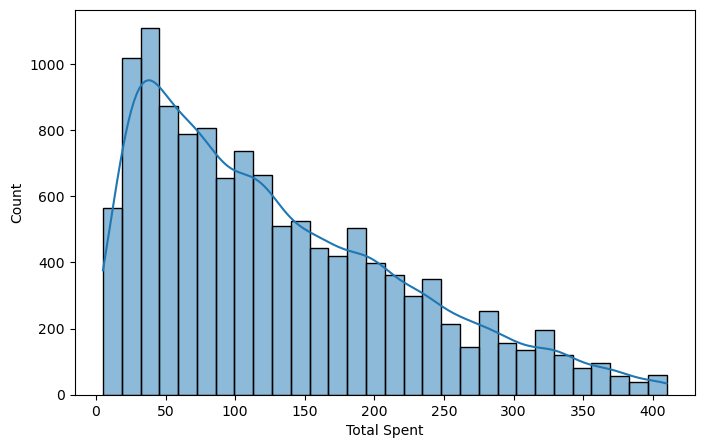

In [15]:
import seaborn as sns 
plt.figure(figsize=(8,5))
sns.histplot(data["Total Spent"], bins = 30, kde=True)

In [16]:
data["Total Spent"] = data["Total Spent"].clip(lower, upper)

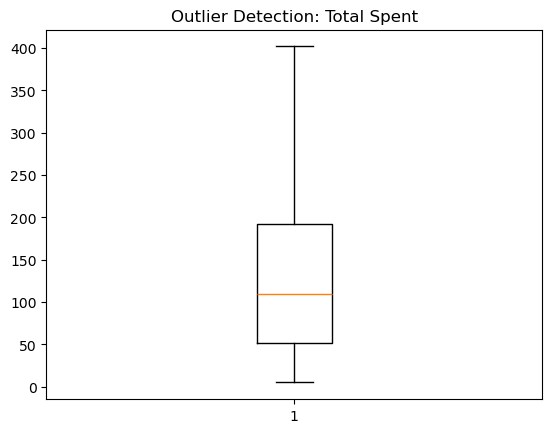

In [17]:
import matplotlib.pyplot as plt
plt.boxplot(data["Total Spent"])
plt.title("Outlier Detection: Total Spent")
plt.show()

<Axes: xlabel='Total Spent', ylabel='Count'>

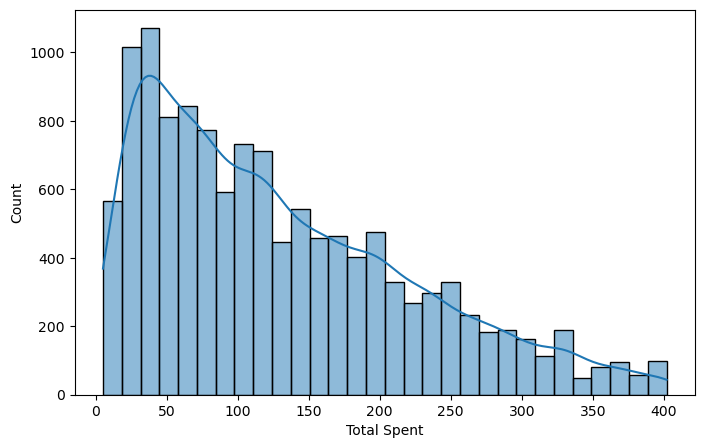

In [18]:
import seaborn as sns 
plt.figure(figsize=(8,5))
sns.histplot(data["Total Spent"], bins = 30, kde=True)

### Interpretation : 
After applying IQR-based clipping on Total Spent, extreme values were capped without removing any records. The boxplot shows no visible outliers and unchanged median, indicating preserved central tendency. The histogram shows a reduced right tail, making the distribution less skewed while maintaining overall data structure.

### Data Handling

> Customer Segmentation Based on Total Spending

In [19]:
bins = [0, 100, 500, 1000, 5000]
labels = ['Low Spender', 'Medium Spender',
          'High Spender', 'Premium Customer']
data['Customer Segment'] = pd.cut(
    data['Total Spent'],
    bins=bins,
    labels=labels)

In [20]:
data[['Total Spent', 'Customer Segment']].head()

,Total Spent,Customer Segment
0,185.0,Medium Spender
1,261.0,Medium Spender
2,43.0,Low Spender
3,247.5,Medium Spender
4,87.5,Low Spender


### Interpretation: 
Customer segmentation was performed on Total Spent using predefined bins. Customers were grouped into Low, Medium, High, and Premium categories based on their spending behavior. This helps convert continuous spending values into meaningful customer groups for better business analysis and targeted decision-making.

> Monthly Sales Analysis

In [21]:
data['Transaction Date'] = pd.to_datetime(data['Transaction Date'])
data['Year'] = data['Transaction Date'].dt.year
data['Month'] = data['Transaction Date'].dt.month
data['Month Name'] = data['Transaction Date'].dt.month_name()
data['Day'] = data['Transaction Date'].dt.day_name()
data['Weekend'] = data['Day'].isin(['Saturday', 'Sunday'])

In [22]:
monthly_sales = data.groupby('Month')['Total Spent'].sum()
print(monthly_sales.sort_values(ascending=False))

Month
1     182868.879041
7     137794.313675
12    136945.752861
6     135399.948125
9     134065.895581
4     131634.690126
5     131450.365341
11    129478.270612
3     129228.183443
8     129100.366928
2     127021.616657
10    125307.889775
Name: Total Spent, dtype: float64


### Interpretation: 
The monthly sales reveals how total revenue is distributed across the twelve months of the year. By sorting the output in descending order, it becomes easy to identify the peak and low sales months. The results show that Month 1 has the highest sales followed by 7th and 12th month, indicating peak customer spending during those periods may correspond to festive seasons, promotional campaigns, or seasonal demand increases common patterns in retail environments. In contrast, 2nd and 10th month revealed lower revenue that may reflect off-peak periods or reduced consumer activity. 

> Top Product Categories by Total Sales

In [23]:
top_categories = data.groupby('Category')['Total Spent'].sum()
print(top_categories.sort_values(ascending=False))

Category
Butchers                              217289.594854
Electric household essentials         214330.130524
Beverages                             206008.712430
Furniture                             204547.117701
Food                                  204324.386768
Computers and electric accessories    201123.952844
Patisserie                            193559.978323
Milk Products                         189112.298722
Name: Total Spent, dtype: float64


### Interpretation: 
The category-wise sales reveals which product categories generate the most revenue in the retail store. By sorting categories in descending order of total spending, one can identify the top-performing product groups that drive the majority of business value. Categories such as Butchers followed by electric household essentials have significantly higher total sales and may represent core product lines that attract frequent or high-value purchases. In contrast, lower-performing categories like milk products may indicate niche products or items with limited demand.This insight helps in making better retail decisions like stocking more popular products, running targeted promotions, and giving more space to high-selling categories in stores.

> Location-wise Total Sales Analysis

In [24]:
location_sales = data.groupby('Location')['Total Spent'].sum()
print(location_sales.sort_values(ascending=False))

Location
Online      828558.939521
In-store    801737.232646
Name: Total Spent, dtype: float64


### Interpretation: 
The location-wise sales analysis shows how revenue is distributed between Online and In-store channels. When sorted in descending order, the results indicate that Online sales generate slightly higher revenue than In-store sales, though both contribute almost equal overall. This suggests that customers actively use both channels, with a small preference for online shopping. Such insights help in balancing resources and improving strategies across both sales channels.

> Category vs Payment Method: Total Spending Analysis

In [25]:
pivot_table = pd.pivot_table(
    data,
    values='Total Spent',
    index='Category',
    columns='Payment Method',
    aggfunc='sum'
)
print(pivot_table)

Payment Method                              Cash   Credit Card  Digital Wallet
Category                                                                      
Beverages                           73328.945326  63963.644098    68716.123006
Butchers                            75390.494361  76341.623883    65557.476610
Computers and electric accessories  71764.069752  67008.460613    62351.422479
Electric household essentials       70885.294712  63512.558683    79932.277128
Food                                73777.689082  66015.870813    64530.826873
Furniture                           70222.462200  68217.700860    66106.954640
Milk Products                       63428.355693  63756.281180    61927.661849
Patisserie                          66073.199273  63382.200860    64104.578189


### Interpretation: 
The pivot table shows total spending across different product categories and payment methods. It helps compare how customers pay when buying from each category. The results show that spending is fairly balanced across Cash, Credit Card, and Digital Wallet, with slight variations depending on the category. This analysis helps understand payment preferences and can support better payment options, targeted offers, and improved customer experience.

> Top 10 Customers by Total Spending

In [26]:
top_customers = data.groupby('Customer ID')['Total Spent'].sum()
top_10 = top_customers.sort_values(ascending=False).head(10)
print(top_10)

Customer ID
CUST_24    71600.345502
CUST_08    70530.295589
CUST_05    70340.923356
CUST_13    68589.196642
CUST_23    68225.288029
CUST_16    67972.347966
CUST_10    66159.290494
CUST_22    65636.256745
CUST_15    65401.561148
CUST_21    65154.001921
Name: Total Spent, dtype: float64


### Interpretation: 
The top 10 customers were identified by summing total spending for each customer and sorting them in descending order. These customers contribute the highest revenue to the business and represent a valuable customer segment. Identifying them helps the business focus on customer retention strategies, loyalty programs, and personalized offers to maintain their engagement and maximize long-term revenue.

### Data Visualization

> Monthly Sales Trend Analysis

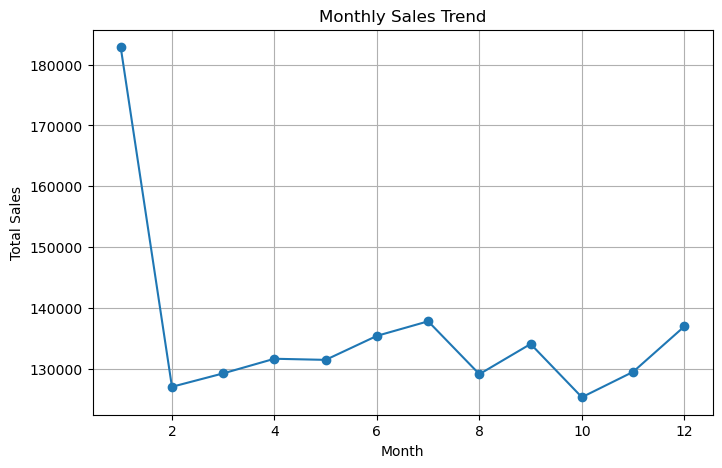

In [27]:
import matplotlib.pyplot as plt
monthly_sales = data.groupby('Month')['Total Spent'].sum()
plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Interpretation: 
The monthly sales trend graph shows that sales were highest in Month 1, indicating a strong start to the year, possibly due to seasonal demand, promotional offers, or holiday shopping. After this peak, sales dropped significantly in Month 2 and then remained relatively stable throughout the remaining months with only minor fluctuations. Small increases in Months 6, 7, and 12 suggest periods of higher customer demand or promotional activity, while Month 10 recorded the lowest sales, indicating a temporary decline in purchases. Overall, the graph reflects a stable sales pattern after an exceptional initial sales spike.

> Category-wise Total Sales

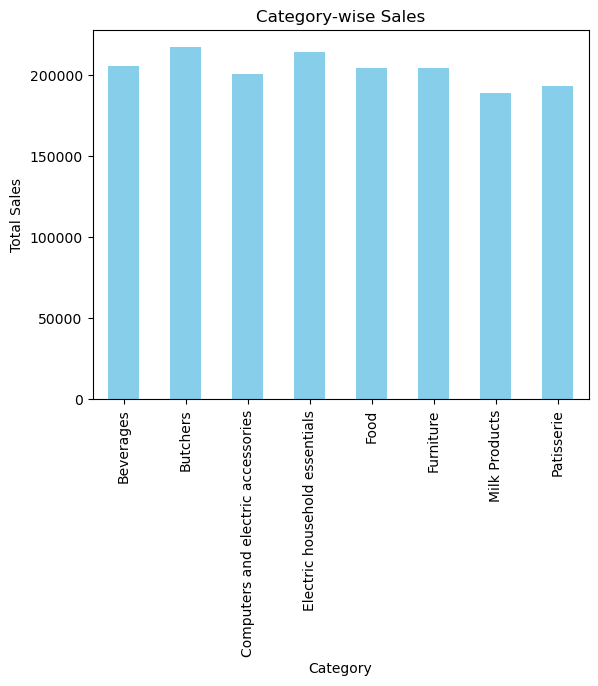

In [28]:
top_categories.plot(kind='bar', color='skyblue')
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Interpretation: 
The category-wise sales graph indicates that sales are fairly evenly distributed across different product categories, showing that the business has a diversified sales structure. Among all categories, Butchers and Electric Household Essentials generated the highest sales, making them the top-performing categories. In contrast, Milk Products recorded the lowest sales, which may indicate lower customer demand or fewer sales opportunities in that category. Other categories such as Beverages, Food, and Furniture also contributed significantly to total revenue, demonstrating balanced performance across the retail business.

> Distribution of Total Spent

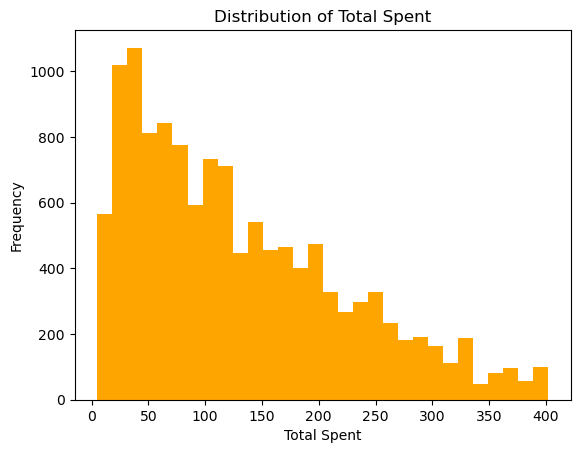

In [29]:
plt.hist(data['Total Spent'], bins=30, color='orange')
plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

### Interpretation:
The histogram shows the distribution of customers total spending amounts. Most transactions are concentrated in the lower spending range, particularly between 0 and 100, indicating that the majority of customers make small to moderate purchases. As the spending amount increases, the frequency of transactions gradually decreases, meaning fewer customers spend very high amounts. The distribution is positively skewed, with a long tail extending toward higher spending values, suggesting the presence of a small number of high-value purchases.

> Correlation Heatmap of Numerical Features

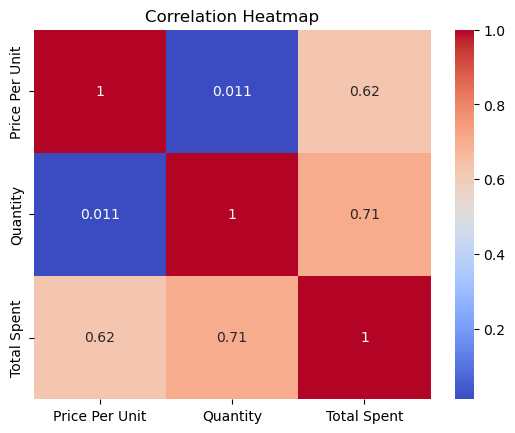

In [30]:
corr = data[['Price Per Unit', 'Quantity', 'Total Spent']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Interpretation:
The correlation heatmap shows the relationship between Price Per Unit, Quantity, and Total Spent. Quantity has the strongest positive correlation with Total Spent (0.71), indicating that customers who buy more items tend to spend more overall. Price Per Unit also has a moderate positive correlation with Total Spent (0.62), meaning higher-priced products contribute to increased spending. However, Price Per Unit and Quantity have almost no correlation (0.011), suggesting that the number of items purchased is largely independent of product price. Overall, both quantity and product price influence total spending, with quantity having the greater impact.

### Feature Extraction & Analysis
> Impact of Quantity on Total Spent

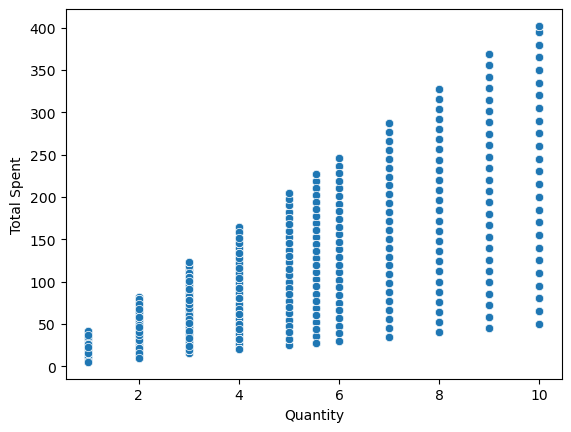

In [31]:
sns.scatterplot(x='Quantity',y='Total Spent',data=data)
plt.show()

### Interpretation: 
The scatter plot shows a clear positive relationship between Quantity and Total Spent. As the quantity of products purchased increases, the total amount spent also increases consistently. Customers buying larger quantities tend to generate higher sales values, with the highest spending observed at quantities close to 10 units. The pattern also indicates relatively stable growth in spending with quantity, confirming that purchase quantity is a major factor influencing total sales revenue.

> Total Spent Distribution Across Payment Methods

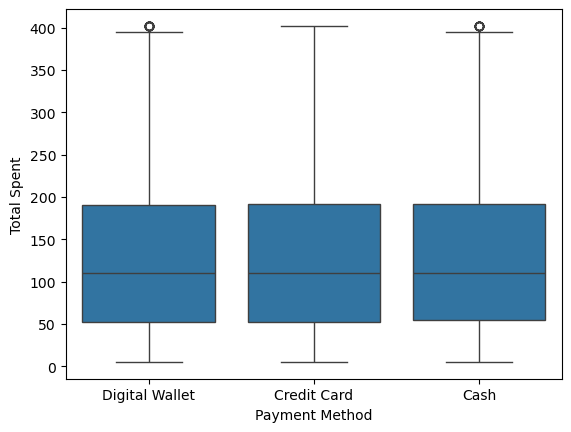

In [32]:
sns.boxplot(x='Payment Method',y='Total Spent',data=data)
plt.show()

### Interpretation: 
The boxplot shows the distribution of total spending across different payment methods, including Digital Wallet, Credit Card, and Cash. The spending patterns are very similar across all three categories, with nearly identical median values and closely aligned interquartile ranges. This indicates that customers tend to spend a similar amount regardless of the payment method they use. The spread of data is also consistent across all groups, showing no major variation in spending behavior. A few outliers are present at higher spending levels (around 400), but overall the distribution suggests that payment method does not have a significant impact on total spending.

> Pairwise Relationships Between Numerical Features

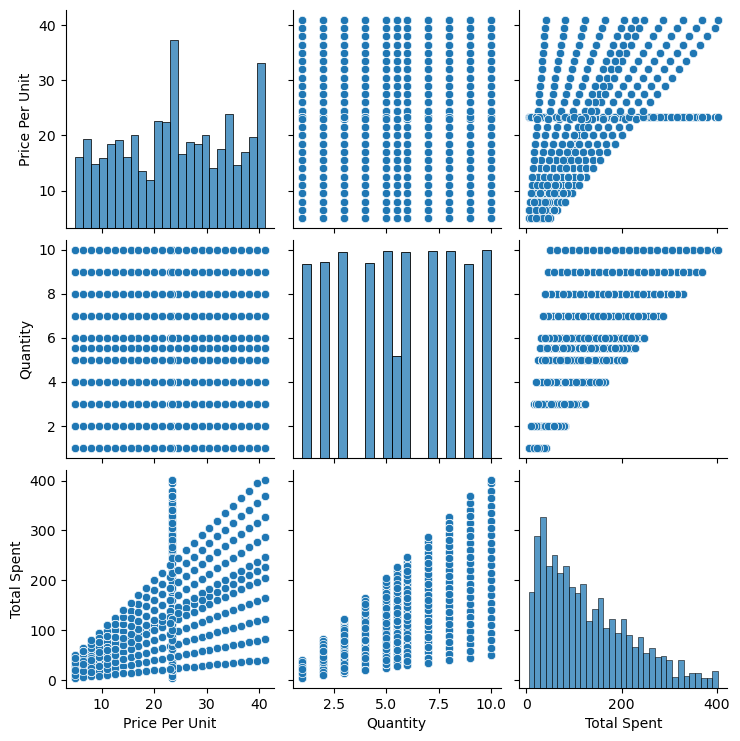

In [33]:
sns.pairplot(data[['Price Per Unit', 'Quantity', 'Total Spent']])
plt.show()

### Interpretation: 
The pairplot shows the relationship between Price Per Unit, Quantity, and Total Spent. The plot indicates that Total Spent increases significantly with Quantity, showing a strong positive relationship where higher quantities lead to higher spending. Similarly, Price Per Unit also shows a positive relationship with Total Spent, but the pattern is less strong and more scattered compared to quantity. The distribution of Total Spent is positively skewed, with most transactions clustered at lower spending values and fewer transactions at higher spending levels. This suggests that most customers make smaller purchases, while a small number of high-value transactions contribute to the upper tail of the distribution.

> Average Item Cost per Transaction

In [34]:
data['Average_Item_Cost'] = data['Total Spent'] / data['Quantity']
data

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Customer Segment,Year,Month,Month Name,Day,Weekend,Average_Item_Cost
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,Medium Spender,2024,4,April,Monday,False,18.5
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,Medium Spender,2023,7,July,Sunday,True,29.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,Low Spender,2022,10,October,Wednesday,False,21.5
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,Medium Spender,2022,5,May,Saturday,True,27.5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,Low Spender,2022,10,October,Sunday,True,12.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,False,Medium Spender,2023,9,September,Sunday,True,38.0
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,Low Spender,2022,8,August,Friday,False,6.5
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,False,Medium Spender,2024,8,August,Saturday,True,14.0
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,Low Spender,2023,12,December,Saturday,True,14.0


### Interpretation: 
The Average_Item_Cost feature was created by dividing Total Spent by Quantity, representing the average cost per item in each transaction. This helps standardize spending behavior across transactions with different quantities and provides a clearer view of item-level pricing patterns. The values are consistent with Price Per Unit, confirming correct feature engineering.

> Weekend vs Weekday Transaction Distribution

In [35]:
data['Weekend'] = data['Day'].isin(['Saturday', 'Sunday']).astype(int)
data

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Customer Segment,Year,Month,Month Name,Day,Weekend,Average_Item_Cost
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,Medium Spender,2024,4,April,Monday,0,18.5
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,Medium Spender,2023,7,July,Sunday,1,29.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,Low Spender,2022,10,October,Wednesday,0,21.5
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,Medium Spender,2022,5,May,Saturday,1,27.5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,Low Spender,2022,10,October,Sunday,1,12.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,False,Medium Spender,2023,9,September,Sunday,1,38.0
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,Low Spender,2022,8,August,Friday,0,6.5
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,False,Medium Spender,2024,8,August,Saturday,1,14.0
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,Low Spender,2023,12,December,Saturday,1,14.0


In [36]:
data["Weekend"].value_counts()

Weekend
0    8977
1    3598
Name: count, dtype: int64

### Interpretation:
The Weekend feature was created to identify whether a transaction occurred on a weekend or weekday. A value of 1 represents weekend transactions (Saturday and Sunday), while 0 represents weekdays. The results show that most transactions occurred on weekdays, indicating higher customer activity during regular working days compared to weekends.

> Variance Inflation Factor (VIF) Analysis for Multicollinearity

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data[['Price Per Unit', 'Quantity', 'Total Spent']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
print(vif_data)

          Feature       VIF
0  Price Per Unit  4.810913
1        Quantity  5.839294
2     Total Spent  9.329291


### Interpretation:
The Variance Inflation Factor (VIF) was calculated to check multicollinearity among numerical features. The results show that Total Spent has the highest VIF (9.33), indicating a strong relationship with other variables, especially Price Per Unit and Quantity. This is expected since Total Spent is derived from these two features. Price Per Unit and Quantity also show moderate VIF values (4.81 and 5.83), indicating some correlation but still within acceptable limits. Overall, the features show moderate multicollinearity, with Total Spent being the most dependent variable.

### Feature Selection

> Correlation of Features with Total Spent

In [38]:
corr_matrix = data.corr(numeric_only=True)
corr_with_target = corr_matrix['Total Spent'].sort_values(ascending=False)
print(corr_with_target)

Total Spent          1.000000
Quantity             0.705113
Average_Item_Cost    0.639525
Price Per Unit       0.624242
Weekend              0.007665
Discount Applied     0.005838
Year                -0.001588
Month               -0.008215
Name: Total Spent, dtype: float64


### Interpretation:
The correlation analysis shows the relationship between Total Spent and other variables. Quantity (0.70), Average Item Cost (0.64), and Price Per Unit (0.62) have strong positive correlations, indicating that they significantly influence total spending. This is expected as Total Spent is directly dependent on these features.
Other variables like Weekend, Discount Applied, Year, and Month show very weak or near-zero correlation, suggesting they have little direct impact on total spending. Overall, the results confirm that spending is mainly driven by quantity and price-related features.

> Principal Component Analysis (PCA) on Scaled Numerical Features

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['Price_scaled', 'Quantity_scaled', 'Total_scaled']] = scaler.fit_transform(
    data[['Price Per Unit', 'Quantity', 'Total Spent']])

In [40]:
from sklearn.decomposition import PCA
features = data[['Price_scaled', 'Quantity_scaled', 'Total_scaled']]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features)
print(pca.explained_variance_ratio_)

[0.6491009  0.32963253]


### Interpretation:
Principal Component Analysis was applied to the scaled numerical features (Price Per Unit, Quantity, and Total Spent) to reduce dimensionality. The results show that the first principal component explains 64.9% of the variance, while the second explains 32.9%, meaning that together they capture about 97.8% of the total information in the data.
This indicates that most of the variability in the dataset can be represented using just two components, making PCA effective for simplifying the dataset while retaining important information.

### Conclusion
The study successfully implemented a complete data acquisition and preprocessing pipeline on a retail sales dataset. The dataset was cleaned by handling missing values, verifying the absence of duplicates, and treating outliers using IQR-based clipping, which significantly reduced skewness while preserving data integrity.
Key exploratory analysis revealed clear business patterns, including Butchers as the top revenue-generating category and noticeable monthly and regional variations in sales. Customer spending was largely influenced by Price Per Unit and Quantity, while payment methods and locations showed relatively balanced contributions. Feature engineering and segmentation further enhanced the dataset by enabling meaningful customer grouping and behavioral insights.
Additionally, PCA demonstrated effective dimensionality reduction by retaining over 97.8% of the variance using just two components, confirming that the dataset can be efficiently represented in a lower-dimensional space without significant information loss.
Overall, the preprocessing and analysis steps transformed raw transactional data into a structured, insight-rich dataset suitable for advanced machine learning tasks such as forecasting, customer segmentation, and demand prediction.